# Exercise 1

In [36]:
def generate_stripe_image(size, stripe_nr, vertical = True):
  img=np.zeros((size,size,1),dtype="uint8")
  for i in range(0,stripe_nr):
    x,y = np.random.randint(0,size,2)
    l  = int(np.random.randint(y,size,1))
    if (vertical):
      img[y:l,x,0]=255
    else:
      img[x,y:l,0]=255
  return img  

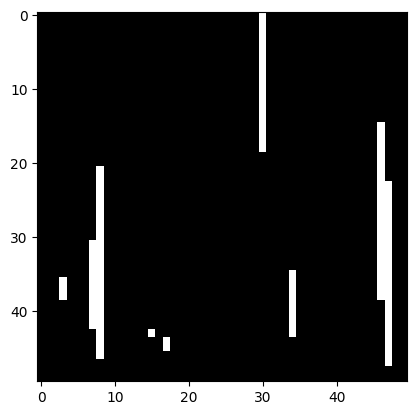

In [37]:
import matplotlib.pyplot as plt
import numpy as np

img=generate_stripe_image(50,10, vertical=True)
plt.imshow(img[:,:,0],cmap='gray')


## Exercise 1.1

### Generate 1000 training and validation images (500 horizontal and 500 vertical)

In [38]:
def generate_sample_images():
    sample_set = []
    for i in range(2):
        for _ in range(500):
            sample_set.append(
                generate_stripe_image(50, 10, vertical=(i == 0))
            )
    return np.array(sample_set, dtype="float32")

# Normalize the images to the range [0, 1]
X_train = generate_sample_images() / 255.0
X_val   = generate_sample_images() / 255.0

## Exercise 1.2

### Create Y_train and Y_val in one-hot encoding format

In [39]:
from tensorflow.keras.utils import to_categorical

In [40]:
Y_train = np.array([0] * 500 + [1] * 500)
Y_val   = np.array([0] * 500 + [1] * 500)

Y_train = to_categorical(Y_train, num_classes=2)
Y_val   = to_categorical(Y_val, num_classes=2)

## Exercise 1.3

### Build a CNN

In [41]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Conv2D(filters=1, kernel_size=(5,5), activation='linear',
                  padding='same', input_shape=(50,50,1)),
    layers.MaxPooling2D(pool_size=(50,50)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])


### Compile the CNN

In [42]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

### How many parameters does the model have?
- Con2D layer:  weights + bias = number of filters $*$ kernel size $*$ number of channels + bias = $1*5*5*1+1 = 26$ parameters
- MaxPooling layer: 0 parameters
- Flatten layer: 0 parameters
- Dense layer:  weights + bias = number of inputs $*$ number of neurons + bias (1 for each neuron) = $1*2+2 = 4$ parameters
- Total parameters among layers: $26 + 0 + 0 + 4 = 30$ parameters

## Exercise 1.4

### Train the model using 50 epochs and a batch size of 64

In [43]:
history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 

Epoch 1/50
16/16 [==============================] - 1s 16ms/step - loss: 0.7015 - accuracy: 0.5000 - val_loss: 0.6981 - val_accuracy: 0.5000
Epoch 2/50
16/16 [==============================] - 0s 9ms/step - loss: 0.6974 - accuracy: 0.5000 - val_loss: 0.6954 - val_accuracy: 0.5000
Epoch 3/50
16/16 [==============================] - 0s 9ms/step - loss: 0.6951 - accuracy: 0.5000 - val_loss: 0.6938 - val_accuracy: 0.5000
Epoch 4/50
16/16 [==============================] - 0s 9ms/step - loss: 0.6937 - accuracy: 0.4950 - val_loss: 0.6929 - val_accuracy: 0.4670
Epoch 5/50
16/16 [==============================] - 0s 9ms/step - loss: 0.6930 - accuracy: 0.4900 - val_loss: 0.6924 - val_accuracy: 0.5610
Epoch 6/50
16/16 [==============================] - 0s 9ms/step - loss: 0.6923 - accuracy: 0.5270 - val_loss: 0.6916 - val_accuracy: 0.5650
Epoch 7/50
16/16 [==============================] - 0s 8ms/step - loss: 0.6913 - accuracy: 0.5390 - val_loss: 0.6901 - val_accuracy: 0.5000
Epoch 8/50
16/16 [=

### Plot training and validation accuracy & training and validation loss

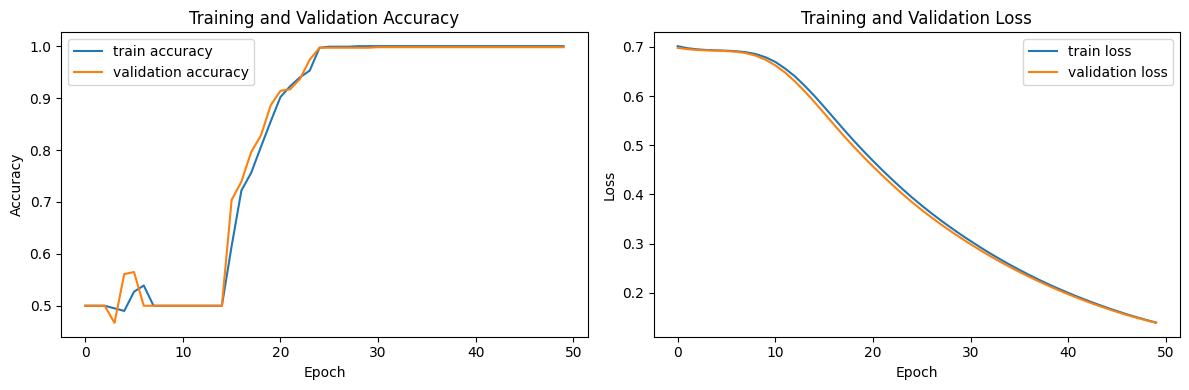

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left plot
ax1.plot(history.history['accuracy'], label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='validation accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Right plot
ax2.plot(history.history['loss'], label='train loss')
ax2.plot(history.history['val_loss'], label='validation loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## Exercise 1.5

### Make a greyscale plot of the kernel

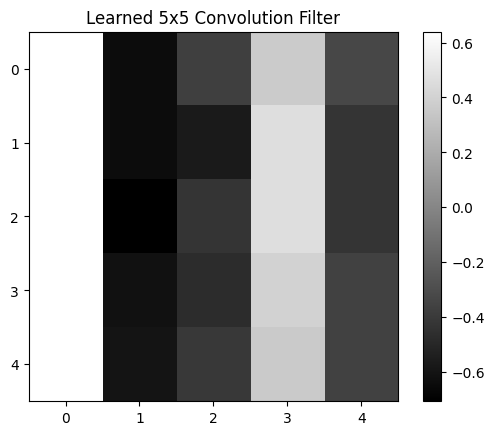

In [45]:
conv_filter=model.get_weights()[0]

plt.imshow(conv_filter[:,:,0,0],cmap='gray')
plt.colorbar()
plt.title('Learned 5x5 Convolution Filter')
plt.show()

### Comments on the visual appearance of the kernel
The learned 5×5 filter shows a clear column‑wise structure. Each column has almost uniform values, while the sign and intensity vary strongly between columns. This means that the kernel changes significantly in the horizontal direction but remains nearly constant in the vertical direction. Such a pattern makes the filter highly sensitive to pixel intensity changes from left to right, which is exactly the type of variation produced by vertical stripes. In contrast, horizontal stripes vary only in the vertical direction, where the filter does not change, resulting in a much weaker response. Therefore, the visual appearance of the kernel is fully consistent with a filter that is capable of distinguishing vertical from horizontal stripes, and in this case it is particularly well‑suited for detecting vertical stripe patterns.

## Exercise 1.6

### Use relu activation instead of a linear activation

Epoch 1/50
16/16 [==============================] - 1s 30ms/step - loss: 0.8929 - accuracy: 0.5000 - val_loss: 0.8511 - val_accuracy: 0.5000
Epoch 2/50
16/16 [==============================] - 0s 13ms/step - loss: 0.8190 - accuracy: 0.5000 - val_loss: 0.7838 - val_accuracy: 0.5000
Epoch 3/50
16/16 [==============================] - 0s 11ms/step - loss: 0.7567 - accuracy: 0.5000 - val_loss: 0.7279 - val_accuracy: 0.5000
Epoch 4/50
16/16 [==============================] - 0s 14ms/step - loss: 0.7057 - accuracy: 0.5000 - val_loss: 0.6797 - val_accuracy: 0.5000
Epoch 5/50
16/16 [==============================] - 0s 25ms/step - loss: 0.6605 - accuracy: 0.5000 - val_loss: 0.6375 - val_accuracy: 0.5000
Epoch 6/50
16/16 [==============================] - 0s 17ms/step - loss: 0.6205 - accuracy: 0.5000 - val_loss: 0.6003 - val_accuracy: 0.5000
Epoch 7/50
16/16 [==============================] - 0s 14ms/step - loss: 0.5857 - accuracy: 0.5000 - val_loss: 0.5675 - val_accuracy: 0.5000
Epoch 8/50
16

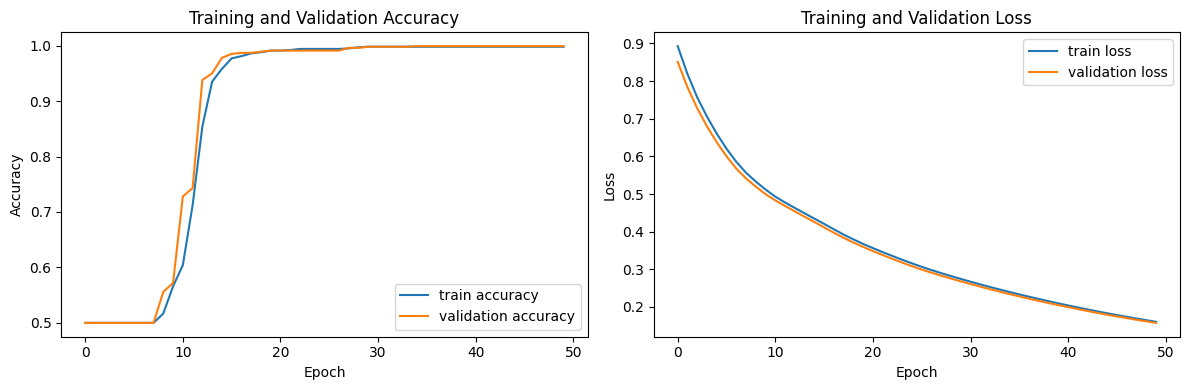

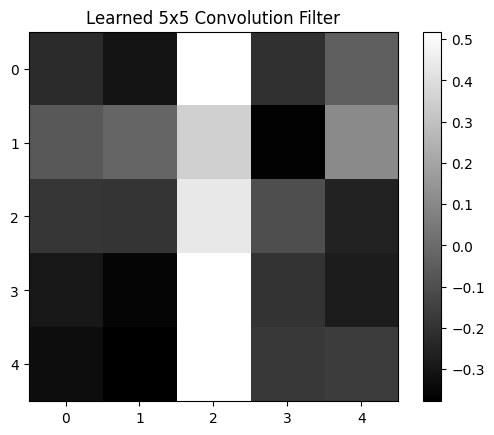

In [46]:
model = models.Sequential([
    layers.Conv2D(filters=1, kernel_size=(5,5), activation='relu',
                  padding='same', input_shape=(50,50,1)),
    layers.MaxPooling2D(pool_size=(50,50)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left plot
ax1.plot(history.history['accuracy'], label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='validation accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Right plot
ax2.plot(history.history['loss'], label='train loss')
ax2.plot(history.history['val_loss'], label='validation loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

conv_filter=model.get_weights()[0]

plt.imshow(conv_filter[:,:,0,0],cmap='gray')
plt.colorbar()
plt.title('Learned 5x5 Convolution Filter')
plt.show()

### Use average pooling instead of max pooling

Epoch 1/50
16/16 [==============================] - 1s 26ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6933 - val_accuracy: 0.5000
Epoch 2/50
16/16 [==============================] - 0s 15ms/step - loss: 0.6934 - accuracy: 0.5000 - val_loss: 0.6933 - val_accuracy: 0.5000
Epoch 3/50
16/16 [==============================] - 0s 22ms/step - loss: 0.6933 - accuracy: 0.5000 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/50
16/16 [==============================] - 0s 25ms/step - loss: 0.6933 - accuracy: 0.5000 - val_loss: 0.6932 - val_accuracy: 0.4990
Epoch 5/50
16/16 [==============================] - 0s 18ms/step - loss: 0.6932 - accuracy: 0.4970 - val_loss: 0.6932 - val_accuracy: 0.4960
Epoch 6/50
16/16 [==============================] - 0s 17ms/step - loss: 0.6932 - accuracy: 0.4880 - val_loss: 0.6932 - val_accuracy: 0.4720
Epoch 7/50
16/16 [==============================] - 0s 16ms/step - loss: 0.6933 - accuracy: 0.4800 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 8/50
16

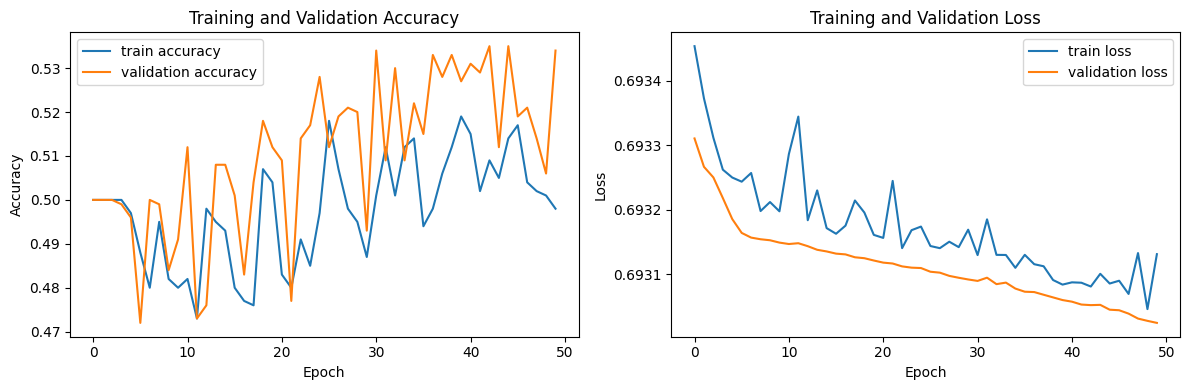

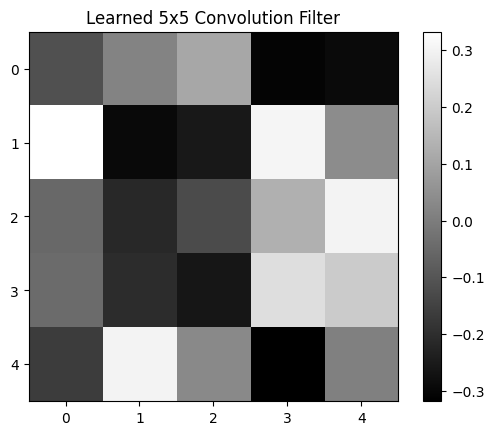

In [48]:
model = models.Sequential([
    layers.Conv2D(filters=1, kernel_size=(5,5), activation='linear',
                  padding='same', input_shape=(50,50,1)),
    layers.AveragePooling2D(pool_size=(50,50)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left plot
ax1.plot(history.history['accuracy'], label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='validation accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Right plot
ax2.plot(history.history['loss'], label='train loss')
ax2.plot(history.history['val_loss'], label='validation loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

conv_filter=model.get_weights()[0]

plt.imshow(conv_filter[:,:,0,0],cmap='gray')
plt.colorbar()
plt.title('Learned 5x5 Convolution Filter')
plt.show()

### Use a different kernel size

Epoch 1/50
16/16 [==============================] - 1s 17ms/step - loss: 0.6960 - accuracy: 0.5000 - val_loss: 0.6879 - val_accuracy: 0.5000
Epoch 2/50
16/16 [==============================] - 0s 9ms/step - loss: 0.6823 - accuracy: 0.5000 - val_loss: 0.6755 - val_accuracy: 0.5000
Epoch 3/50
16/16 [==============================] - 0s 9ms/step - loss: 0.6702 - accuracy: 0.5000 - val_loss: 0.6643 - val_accuracy: 0.5000
Epoch 4/50
16/16 [==============================] - 0s 10ms/step - loss: 0.6615 - accuracy: 0.5000 - val_loss: 0.6581 - val_accuracy: 0.5000
Epoch 5/50
16/16 [==============================] - 0s 9ms/step - loss: 0.6553 - accuracy: 0.5000 - val_loss: 0.6519 - val_accuracy: 0.5000
Epoch 6/50
16/16 [==============================] - 0s 12ms/step - loss: 0.6490 - accuracy: 0.5000 - val_loss: 0.6450 - val_accuracy: 0.5000
Epoch 7/50
16/16 [==============================] - 0s 13ms/step - loss: 0.6420 - accuracy: 0.5000 - val_loss: 0.6378 - val_accuracy: 0.5000
Epoch 8/50
16/16

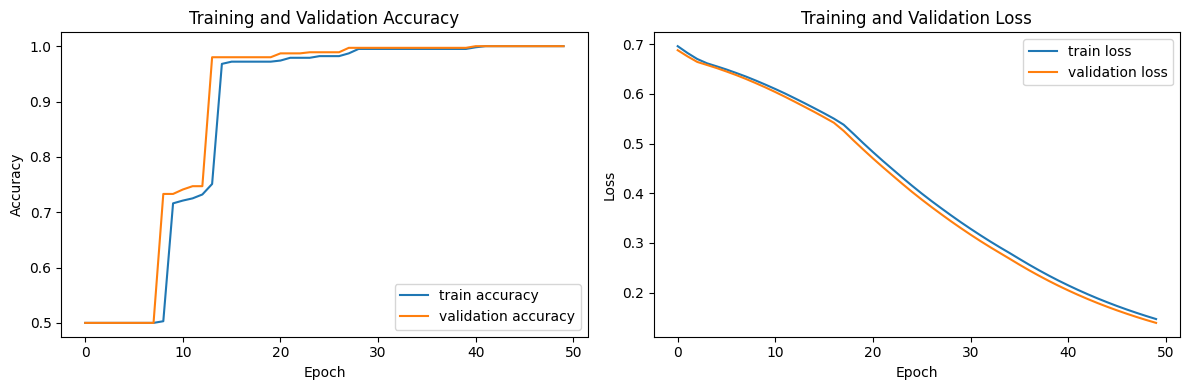

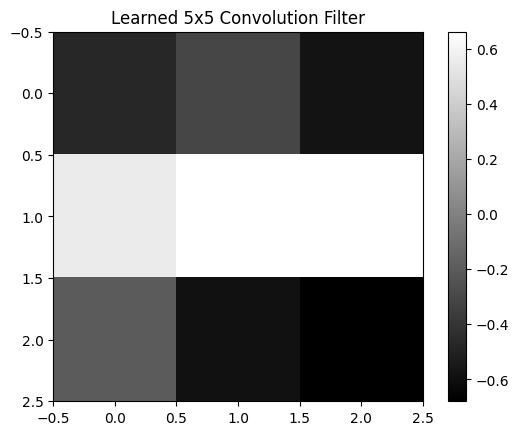

In [49]:
model = models.Sequential([
    layers.Conv2D(filters=1, kernel_size=(3,3), activation='linear',
                  padding='same', input_shape=(50,50,1)),
    layers.MaxPooling2D(pool_size=(50,50)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left plot
ax1.plot(history.history['accuracy'], label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='validation accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Right plot
ax2.plot(history.history['loss'], label='train loss')
ax2.plot(history.history['val_loss'], label='validation loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

conv_filter=model.get_weights()[0]

plt.imshow(conv_filter[:,:,0,0],cmap='gray')
plt.colorbar()
plt.title('Learned 5x5 Convolution Filter')
plt.show()

### Summary
When modifying the model, all three changes had a noticeable impact on the learned kernel and performance. Using a ReLU activation slightly degraded the result, as the learned filter no longer showed as clear a column-wise structure, likely due to the loss of negative activations that are important for capturing contrast. Replacing max pooling with average pooling had a much stronger negative effect since the learned kernel no longer exhibited any clear pattern, and both training accuracy and loss worsened significantly, suggesting that averaging weakened the important signals needed to detect stripe orientation. Finally, reducing the kernel size from 5x5 to 3x3 also led to worse performance, although some structure was still visible. Interestingly, the pattern shifted from column-wise variation to row-wise variation, indicating that the model adapted but with a reduced ability to capture the full spatial structure of the stripes.